In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mounted at /content/drive
Période retenue : 1981-2010, shape SST = (360, 180, 360)


/tmp/ipython-input-1548623039.py:77: RuntimeWarning: Mean of empty slice
  sst_clim[m-1, :, :] = np.nanmean(sst_detrend[months == m, :, :], axis=0)


SST anomaly shape: (360, 180, 360)
Weights shape: (180, 1)


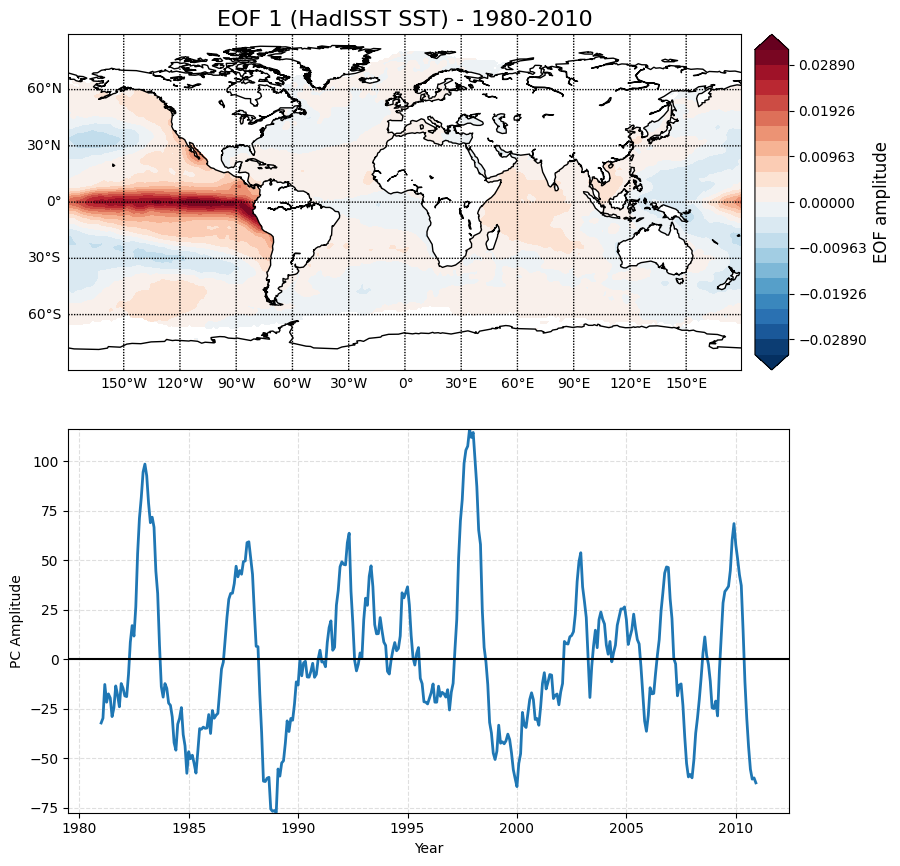

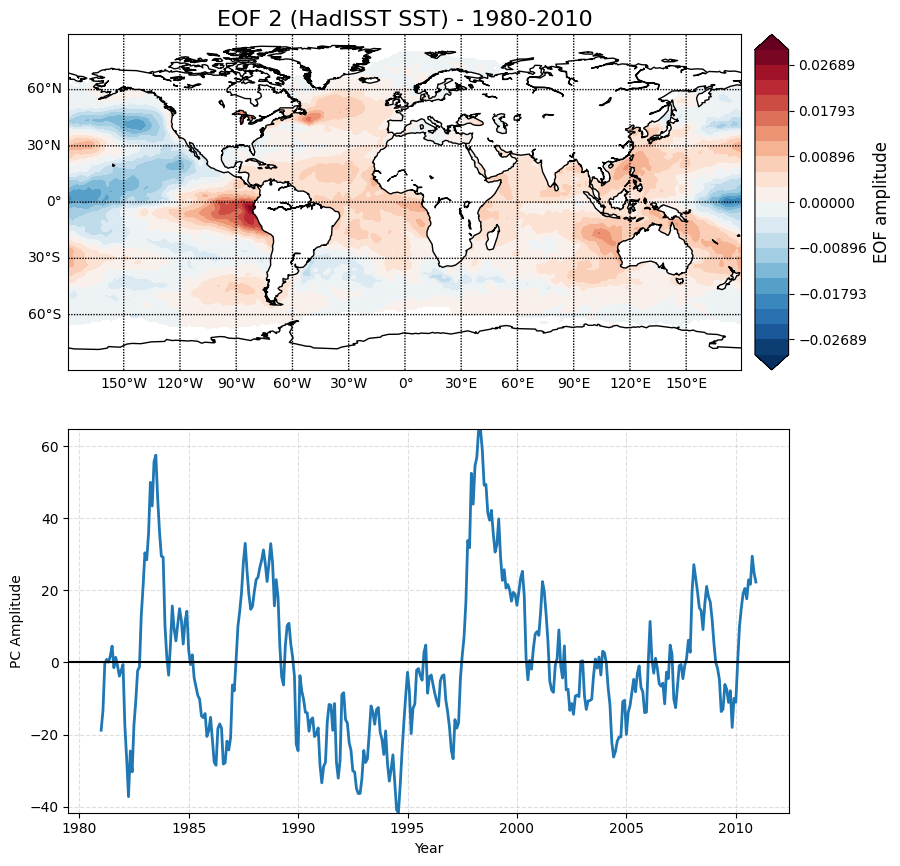

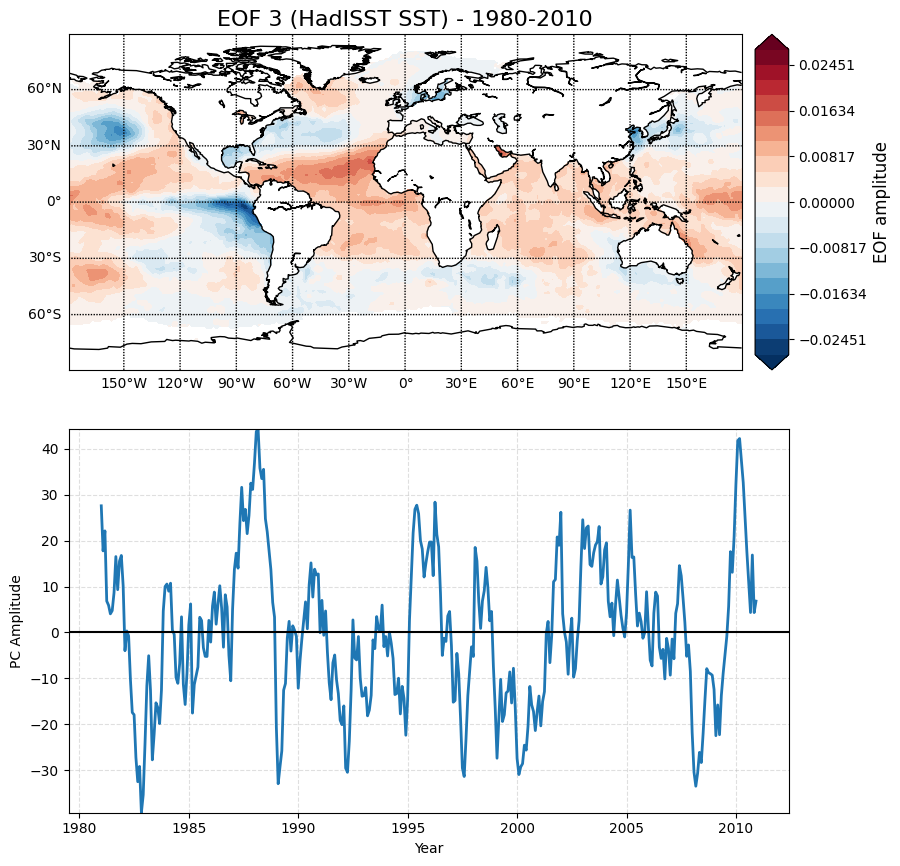

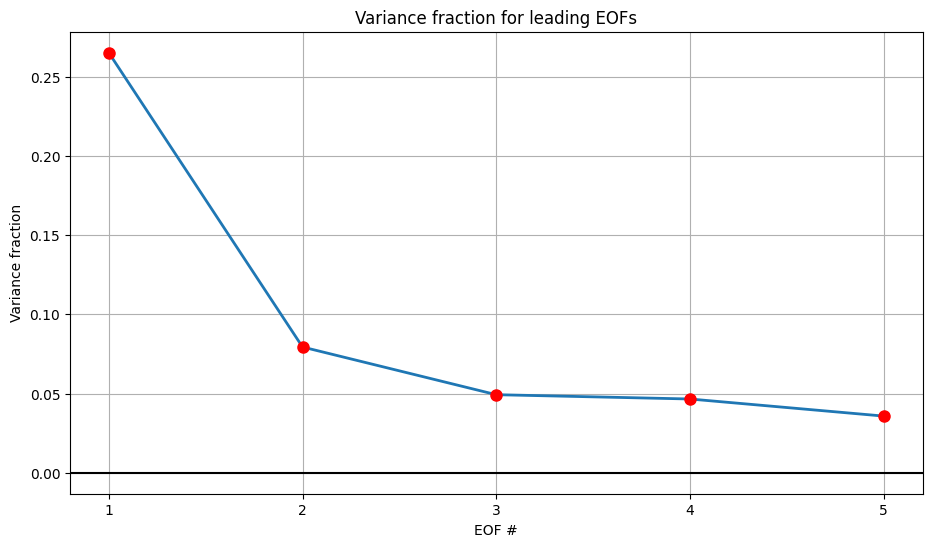

EOF 1 explains 26.5% of total variance
EOF 2 explains 7.9% of total variance
EOF 3 explains 4.9% of total variance
EOF 4 explains 4.7% of total variance
EOF 5 explains 3.6% of total variance


In [158]:
# -*- coding: utf-8 -*-
"""
EOF Analysis - HadISST SST (logic NOAA)
"""

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install netCDF4 eofs basemap

import numpy as np
from netCDF4 import Dataset, num2date
from eofs.standard import Eof
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# -----------------------------
# 1. Load HadISST SST data
# -----------------------------
infile = "/content/drive/MyDrive/phd/data/HadISST_sst.nc"
ds = Dataset(infile)

sst = ds.variables['sst'][:]        # (time, lat, lon)
lat = ds.variables['latitude'][:]
lon = ds.variables['longitude'][:]
time = ds.variables['time']
dates = num2date(time[:], time.units)

# Remplacer valeurs manquantes par np.nan
sst = np.where(sst < -100, np.nan, sst)

ds.close()

# -----------------------------
# 2. Select exact NOAA period (1982-2000)
# -----------------------------
tmask = np.array([(d.year >= 1981) & (d.year <= 2010) for d in dates])
sst = sst[tmask, :, :]
dates = np.array(dates)[tmask]

nt, nlat, nlon = sst.shape
year1 = dates[0].year
year2 = dates[-1].year
print(f"Période retenue : {year1}-{year2}, shape SST = {sst.shape}")

# -----------------------------
# 3. Sort longitude from -180 to 180 (NOAA convention)
# -----------------------------
lon = ((lon + 180) % 360) - 180
idx = np.argsort(lon)
lon = lon[idx]
sst = sst[:, :, idx]

# -----------------------------
# 4. Remove linear trend at each grid point
# -----------------------------
sst_detrend = np.empty_like(sst)
sst_detrend[:] = np.nan
x = np.arange(nt)

for i in range(nlat):
    for j in range(nlon):
        y = sst[:, i, j]
        mask = ~np.isnan(y)
        if np.sum(mask) > 1:
            coefs = np.polyfit(x[mask], y[mask], 1)
            trend = np.polyval(coefs, x[mask])
            sst_detrend[mask, i, j] = y[mask] - trend

# -----------------------------
# 5. Remove monthly climatology
# -----------------------------
months = np.array([d.month for d in dates])
sst_clim = np.full((12, nlat, nlon), np.nan)

for m in range(1, 13):
    sst_clim[m-1, :, :] = np.nanmean(sst_detrend[months == m, :, :], axis=0)

# Subtract climatology to get anomalies
sst_anom = np.empty_like(sst_detrend)
for i, m in enumerate(months):
    sst_anom[i, :, :] = sst_detrend[i, :, :] - sst_clim[m-1, :, :]

# -----------------------------
# 6. EOF analysis
# -----------------------------
# Cosine latitude weights (NOAA uses cos(lat), not sqrt)
weights = np.cos(np.deg2rad(lat))[:, np.newaxis]

solver = Eof(sst_anom, weights=weights)
eofs = solver.eofs(neofs=5)
pcs = solver.pcs(npcs=5, pcscaling=0)
varfrac = solver.varianceFraction()

print("SST anomaly shape:", sst_anom.shape)
print("Weights shape:", weights.shape)

# -----------------------------
# 7. Plot EOFs and PCs
# -----------------------------
parallels = np.arange(-90, 90, 30.)
meridians = np.arange(-180, 180, 30.)

for i in range(3):
    fig = plt.figure(figsize=(9, 9))

    # EOF map
    plt.subplot(211)
    m = Basemap(projection='cyl',
                llcrnrlon=min(lon), llcrnrlat=min(lat),
                urcrnrlon=max(lon), urcrnrlat=max(lat))

    Lon, Lat = np.meshgrid(lon, lat)
    x, y = m(Lon, Lat)

    eof = eofs[i, :, :]
    vmax = np.nanmax(np.abs(eof))
    clevs = np.linspace(-vmax, vmax, 21)

    cs = m.contourf(x, y, eof, clevs, cmap=plt.cm.RdBu_r, extend='both')
    m.drawcoastlines()
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[1,0,0,1])

    cb = m.colorbar(cs, 'right', size='5%', pad='2%')
    cb.set_label('EOF amplitude', fontsize=12)
    plt.title(f'EOF {i+1} (HadISST SST) - 1980-2010', fontsize=16)

    # PC time series
    plt.subplot(212)
    years_for_plot = np.array([d.year + (d.month-1)/12 for d in dates])
    plt.plot(years_for_plot, pcs[:, i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xlabel('Year')
    plt.ylabel('PC Amplitude')
    plt.ylim(np.nanmin(pcs[:, i]), np.nanmax(pcs[:, i]))
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# -----------------------------
# 8. Scree plot
# -----------------------------
plt.figure(figsize=(11,6))
eof_num = range(1, 6)
plt.plot(eof_num, varfrac[:5], linewidth=2)
plt.plot(eof_num, varfrac[:5], 'ro', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 6))
plt.title('Variance fraction for leading EOFs')
plt.xlabel('EOF #')
plt.ylabel('Variance fraction')
plt.grid(True)
plt.show()

for i in range(5):
    print(f"EOF {i+1} explains {varfrac[i]*100:.1f}% of total variance")


# EOF analysis - Global SST

In statistics and signal processing, the method of empirical orthogonal function (EOF) analysis is a decomposition of a signal or data set in terms of orthogonal basis functions which are determined from the data. It is similar to performing a principal components analysis on the data, except that the EOF method finds both temporal projections and spatial patterns. The term is also interchangeable with the geographically weighted PCAs in geophysics (https://en.wikipedia.org/wiki/Empirical_orthogonal_functions). The spatial patterns are the EOFs and can be thought of as basis functions in terms of variance. The associated temporal projections are the principal components (PCs) and are the temporal coefficients of the EOF patterns.

* Python EOF library

> The EOF library is used here from Dawson (http://ajdawson.github.io/eofs/).
> eofs is a Python package for EOF analysis of spatial-temporal data. Using EOFs (empirical orthogonal functions) is a common technique to decompose a signal varying in time and space into a form that is easier to interpret in terms of spatial and temporal variance. Some of the key features of eofs are:

> * Suitable for large data sets: computationally efficient for the large output data sets of modern climate models.
> * Transparent handling of missing values: missing values are removed automatically during computations and placed back into output fields.
> * Automatic metadata: metadata from input fields is used to construct metadata for output fields.
> * No Compiler required: a fast implementation written in pure Python using the power of numpy, no Fortran or C dependencies.

* Data Source

> NOAA Optimum Interpolation (OI) Sea Surface Temperature (SST) V2 is downloaded from https://www.esrl.noaa.gov/psd/data/gridded/data.noaa.oisst.v2.html.
>
> Spatial Coverage:
> * 1.0 degree latitude x 1.0 degree longitude global grid (180x360).
> * 89.5N - 89.5S, 0.5E - 359.5E.
>
> We select SST from 1982 to 2000.

## 1. Load basic libraries

In [4]:
!pip install netCDF4
!pip install eofs
!pip install basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3


In [7]:
import numpy as np
from scipy import signal
import numpy.polynomial.polynomial as poly
from netCDF4 import Dataset

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import Dataset, num2date

## 2. Load SST and mask data

### 2.1 Read SST

In [142]:
from netCDF4 import Dataset, num2date
import numpy as np
from eofs.standard import Eof

ds = Dataset("/content/drive/MyDrive/phd/data/HadISST_sst.nc")

sst = ds.variables["sst"][:]          # (time, lat, lon)
lat = ds.variables["latitude"][:]
lon = ds.variables["longitude"][:]
time = ds.variables["time"]
dates = num2date(time[:], time.units)

# Masque terre HadISST (CRITIQUE)
sst = np.where(sst < -100, np.nan, sst)

ds.close()



In [143]:
print(dates[0], dates[-1])  # Premier et dernier mois

1870-01-16 11:59:59.505615 2024-01-16 12:00:00


In [144]:
tmask = np.array([(d.year >= 1981) & (d.year <= 2010) for d in dates])


In [145]:
sst = sst[tmask, :, :]
dates = np.array(dates)[tmask]

nt, nlat, nlon = sst.shape
year1 = dates[0].year
year2 = dates[-1].year

print(f"Période retenue : {year1} – {year2}, shape sst = {sst.shape}")



Période retenue : 1981 – 2010, shape sst = (360, 180, 360)


In [146]:
lon = ((lon + 180) % 360) - 180
idx = np.argsort(lon)
lon = lon[idx]
sst = sst[:, :, idx]


In [147]:
months = np.array([d.month for d in dates])

sst_clim = np.full((12, nlat, nlon), np.nan)
for m in range(1, 13):
    sst_clim[m-1] = np.nanmean(sst[months == m], axis=0)

sst_anom = np.empty_like(sst)
for i, m in enumerate(months):
    sst_anom[i] = sst[i] - sst_clim[m-1]


/tmp/ipython-input-2143910027.py:5: RuntimeWarning: Mean of empty slice
  sst_clim[m-1] = np.nanmean(sst[months == m], axis=0)


### 2.2 Read mask (1=ocen, 0=land)

In [148]:
weights = np.sqrt(np.cos(np.deg2rad(lat)))[:, np.newaxis]
solver = Eof(sst_anom, weights=weights)


eofs = solver.eofs(neofs=5)          # top 5 EOFs
pcs = solver.pcs(npcs=5, pcscaling=0)  # top 5 PCs

# Variance expliquée
varfrac = solver.varianceFraction()

In [149]:
print(sst_anom.shape)   # (time, lat, lon)
print(weights.shape)    # (lat, 1)


(360, 180, 360)
(180, 1)


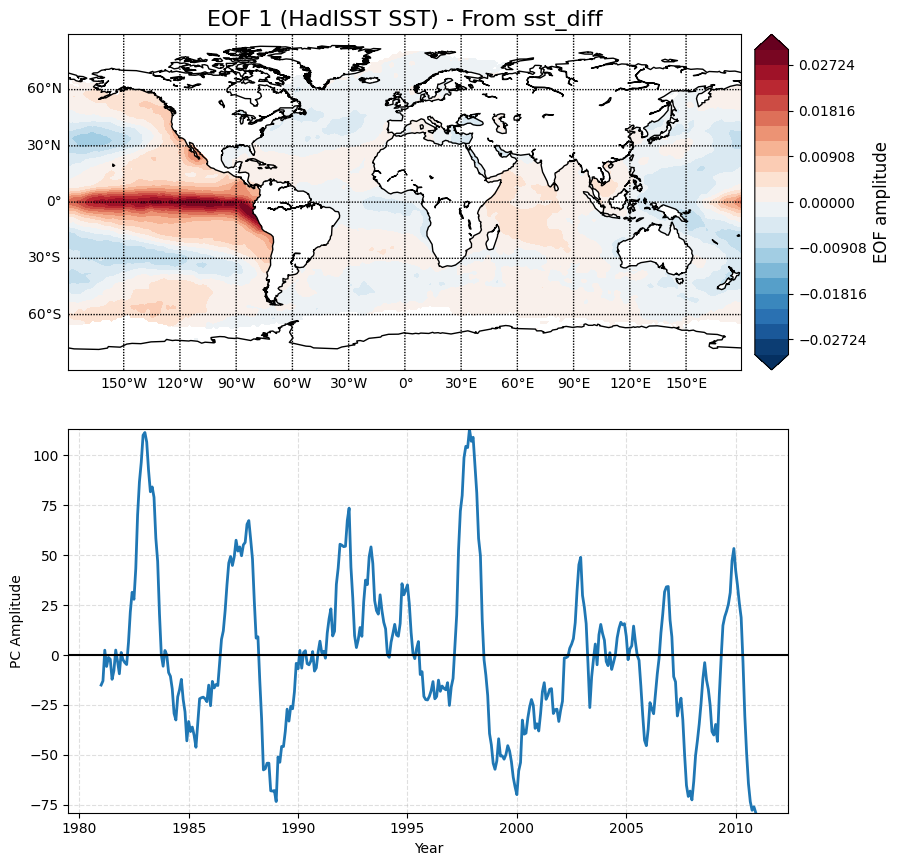

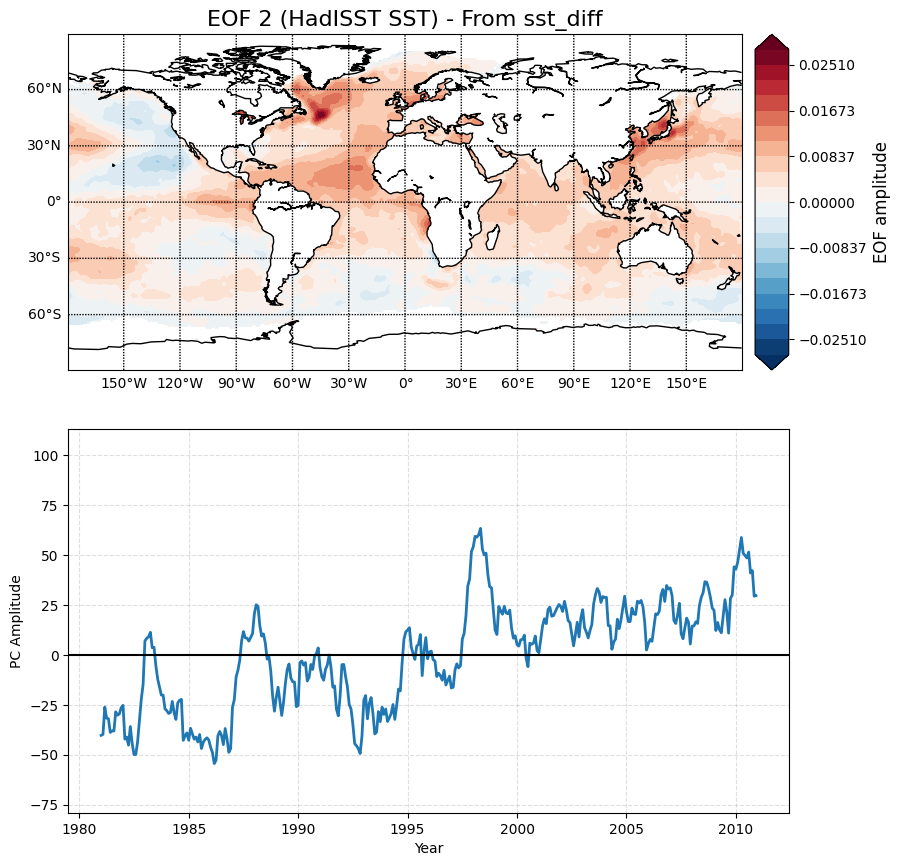

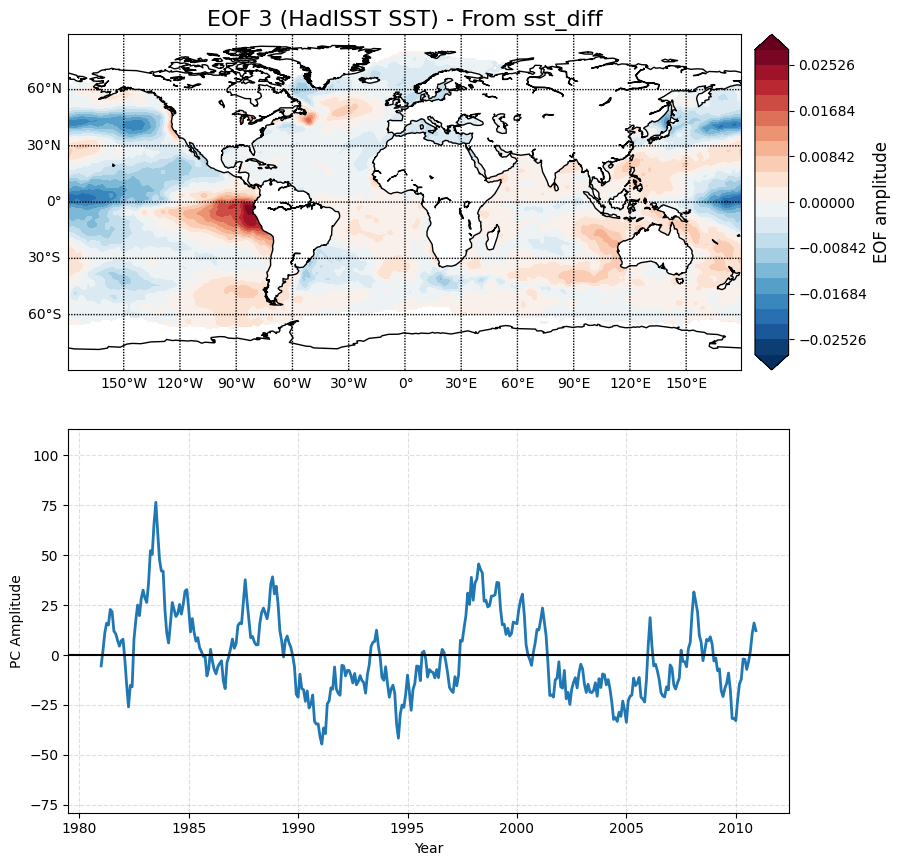

In [150]:
parallels = np.arange(-90, 90, 30.)
meridians = np.arange(-180, 180, 30.)

for i in range(0, 3):

    fig = plt.figure(figsize=(9, 9))

    # ===== EOF MAP =====
    plt.subplot(211)

    m = Basemap(
        projection='cyl',
        llcrnrlon=min(lon),
        llcrnrlat=min(lat),
        urcrnrlon=max(lon),
        urcrnrlat=max(lat)
    )

    Lon, Lat = np.meshgrid(lon, lat)
    x, y = m(Lon, Lat)

    # Use eof1 instead of eofs
    eof = eofs[i, :, :]

    vmax = np.nanmax(np.abs(eof))
    clevs = np.linspace(-vmax, vmax, 21)

    cs = m.contourf(
        x, y, eof,
        clevs,
        cmap=plt.cm.RdBu_r,
        extend='both'
    )

    m.drawcoastlines()
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[1,0,0,1])

    cb = m.colorbar(cs, 'right', size='5%', pad='2%')
    cb.set_label('EOF amplitude', fontsize=12)

    plt.title('EOF ' + str(i+1) + ' (HadISST SST) - From sst_diff', fontsize=16)

    # ===== PC TIME SERIES =====
    plt.subplot(212)

    # Crée un axe temps à partir des dates réelles
    years_for_plot = np.array([d.year + (d.month-1)/12 for d in dates])

    plt.plot(years_for_plot, pcs[:, i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xlabel('Year')
    plt.ylabel('PC Amplitude')
    plt.ylim(np.nanmin(pcs), np.nanmax(pcs))
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

(2.2144422797201746e-15, 0.23549455404281616)

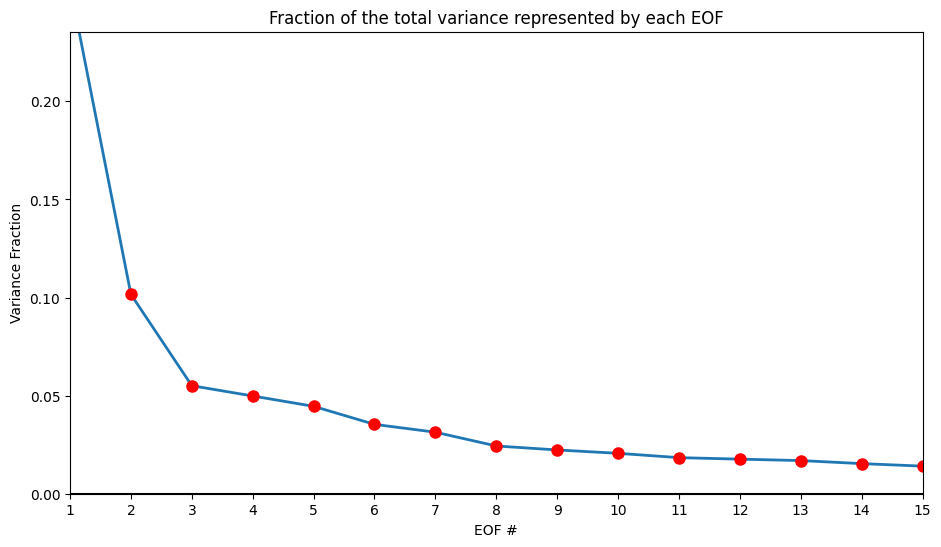

In [151]:
plt.figure(figsize=(11,6))
eof_num = range(1, 16)
plt.plot(eof_num, var[0:15], linewidth=2)
plt.plot(eof_num, var[0:15], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16))
plt.title('Fraction of the total variance represented by each EOF')
plt.xlabel('EOF #')
plt.ylabel('Variance Fraction')
plt.xlim(1, 15)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
#plt.savefig('ScreePlot-Explained-Variance.png')
#plt.savefig('ScreePlot-Explained-Variance.pdf')


In [153]:
sum = 0
for i in range(0, 5):
    sum = sum + round(var[i]*100)
    print("EOF", i, "explain", round(varfrac[i]*100), "%",", variance Cumulée :", sum, "%")

EOF 0 explain 23 % , variance Cumulée : 26 %
EOF 1 explain 10 % , variance Cumulée : 36 %
EOF 2 explain 6 % , variance Cumulée : 42 %
EOF 3 explain 5 % , variance Cumulée : 47 %
EOF 4 explain 4 % , variance Cumulée : 51 %
